In [1]:
from collections import OrderedDict
import torchvision
import torch
from zipfile import ZipFile
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import importlib
import numpy as np
import matplotlib.pyplot as plt


## Transforms With Params
Of Note: the below transform returns (1) A clean and augmented view of an image and (2) the mean-centered/unit-variance standardized parameters of the transformations applied to obtain the augmented view. Come to think of it, you could just normalize right before the regression step, but c'est la vie.

Subsequent cells define the dataset class (similar to `imagenet_100_dataloading.ipynb` example, and a helper function for getting the train/test datasets).

In [2]:
from torchvision.transforms import RandomResizedCrop, ToTensor
import numpy as np
from typing import List
from tqdm import tqdm
import matplotlib.pyplot as plt

import torchaudio
import random
import scipy
import sys
import chcochleagram
from chcochleagram import compression
from chcochleagram import cochleagram
from chcochleagram import *
import logging
import sox 
import robustness.audio_functions.audio_transforms as at
importlib.reload(at)

class AudioAugmentStackWithParams(object):
    def __init__(self, low_db=-10, high_db=10):
        super().__init__()
        self.np_set_dbSPL = at.DBSPLNormalizeForegroundAndBackground(dbspl=60, use_np=True)
        self.torch_set_dbSPL = at.DBSPLNormalizeForegroundAndBackground(dbspl=60, use_np=False)
        self.crop = at.CenterCrop(crop_length=40_000) # crop to middle 2 seconds

        self.combine_db_snr = at.CombineWithRandomDBSNRWithParam(low_db, high_db)
        self.Pitch = at.ApplySingleAugmentSox('pitch', return_params=True)
        self.Tempo = at.ApplySingleAugmentSox('tempo', return_params=True)
        self.Filter = at.ApplySingleAugmentSox('filter', return_params=True)

    def __call__(self, aud, background):
        logging.getLogger('sox').setLevel(logging.ERROR)

        assert aud is not None, " aud is None on input"
        clean_aud = self.crop(aud)
        assert clean_aud is not None, "clean aud is None post crop"
        clean_aud, background = self.np_set_dbSPL(clean_aud, background)
        # apply augmentations
        # sox aug first to match ssl training 
        assert clean_aud is not None, "clean aud is None post set level"
        aug_aud, n_semitones =  self.Pitch(clean_aud)
        aug_aud, temp_shift = self.Tempo(aug_aud)
        aug_aud, (order, low_cutoff, high_cutoff) = self.Filter(aug_aud)
        aug_aud = torch.from_numpy(aug_aud)
        background = torch.from_numpy(background)
        aug_aud, db_snr = self.combine_db_snr(aug_aud, background)
        aug_aud, _ = self.torch_set_dbSPL(aug_aud, None)
        aug_aud = aug_aud.reshape(1,-1)
        params = torch.tensor([db_snr, n_semitones, temp_shift, order, low_cutoff, high_cutoff])
        clean_aud = torch.from_numpy(clean_aud).reshape(1,-1)
        return (clean_aud, aug_aud), params





In [3]:
from lightning_scripts.jsinV3DataLoader_precombined_batched import jsinV3_precombined_all_signals

batch_size = 96
jsin_path = '/mnt/ceph/users/jfeather/data/training_datasets_audio/JSIN_all_v3/subsets/'

train_dataset = jsinV3_precombined_all_signals(root=jsin_path,
                                        train=True,
                                        transform=None,
                                        batch_size=batch_size,
                                        train_max=5  # 10% of training set 
                                        )
val_dataset = jsinV3_precombined_all_signals(root=jsin_path,
                                        train=False,
                                        transform=None,
                                        batch_size=batch_size,
                                        eval_max=1)

In [4]:
transforms = AudioAugmentStackWithParams()

def collate_fn(batch):
    batch = batch[0] # unbox wrapper added by dataloader 
    clean_signals = []
    augmented_signals = []
    params = []
    labels = batch[-1] # labels already collated 
    # convert labels to torch tensors 
    if isinstance(labels, dict):
        for task_key, task_labels in labels.items():
            labels[task_key] = torch.from_numpy(task_labels)
    else:
        labels = torch.from_numpy(labels) 
    # convert signal and noise into signal
    for (signal, noise) in  zip(*batch[:2]):
        if signal.sum() == 0 or signal is None:
            continue 
        if noise.sum() == 0: 
            continue
        else:
            (clean_sig, augment_sig), params_i = transforms(signal, noise)
            clean_signals.append(clean_sig)
            augmented_signals.append(augment_sig)
            params.append(params_i)
    clean_signals = torch.cat(clean_signals).unsqueeze(1).float() # add back channel dim
    augmented_signals = torch.cat(augmented_signals).unsqueeze(1).float() # add back channel dim
    params = torch.stack(params) # add back channel dim
    return clean_signals, augmented_signals, params, labels 

In [5]:
train_loader = torch.utils.data.DataLoader(
            train_dataset,
            batch_size=1,
            shuffle=False,
            num_workers=10,
            pin_memory=True,
            collate_fn=collate_fn
        )
test_loader = torch.utils.data.DataLoader(
            val_dataset,
            batch_size=1,
            shuffle=False,
            num_workers=10,
            pin_memory=True,
            collate_fn=collate_fn
        )


In [6]:
clean, aug, params, _ =  next(iter(train_loader))


In [7]:
from IPython.display import display, Audio


eg_ix = 0
display(Audio(clean[eg_ix], rate=20_000, normalize=False))
display(Audio(aug[eg_ix], rate=20_000, normalize=False))
params[eg_ix]

tensor([ 8.4239e+00, -1.3236e-01,  9.1146e-01,  1.0000e+00,  1.3698e+02,
         9.9960e+03], dtype=torch.float64)

## Feature Extraction

- load a pair of models
- extract features in response to clean/augmented views for each

In [8]:
x = torch.rand(20)
x = x.view(1,-1)

torch.cat([x,x]).shape

torch.Size([2, 20])

In [ ]:
def get_rep_wrapped_model(model, input, layer):
    if layer == 'invar_head':
        feature, rep, logits = model(input)
        if len(rep) == 2:
            rep, _ = rep
    elif layer == 'equivar_head':
        feature, (_, rep), logits = model(input)
    else:
        predictions, rep, all_outputs = model(input,  with_latent=True, fake_relu=False)
        rep = all_outputs[layer]
    rep = rep.flatten(start_dim=1)
    return rep
  
def extract_features_param_decoding(model_1, model_2, loader, layer='avgpool', num_batches=None):
    if num_batches is None:
        num_batches = len(loader)

    responses_clean_1, responses_augmented_1, responses_clean_2, responses_augmented_2,  = [], [], [], []
    params, labels = [], []
    n_ = 0
    with torch.no_grad():
        for clean_audio, augmented_audio, param, label in tqdm(loader):
            clean_audio = clean_audio.cuda()
            augmented_audio = augmented_audio.cuda()
            responses_clean_1.append(get_rep_wrapped_model(model_1, clean_audio, layer))
            responses_augmented_1.append(get_rep_wrapped_model(model_1, augmented_audio, layer))
            responses_clean_2.append(get_rep_wrapped_model(model_2, clean_audio, layer))
            responses_augmented_2.append(get_rep_wrapped_model(model_2, augmented_audio, layer))

            params.append(param)
            labels.append(label)
        n_ += 1
        if n_ == num_batches:
            break

    responses_clean_1 = torch.cat(responses_clean_1)
    responses_augmented_1 = torch.cat(responses_augmented_1)
    responses_clean_2 = torch.cat(responses_clean_2)
    responses_augmented_2 = torch.cat(responses_augmented_2)

    params = torch.cat(params)
    # labels = torch.cat(labels)

    return responses_clean_1, responses_augmented_1, responses_clean_2, responses_augmented_2, params, None

SyntaxError: 'break' outside loop (3066195958.py, line 37)

In [27]:
import yaml 
from lightning_scripts.lightning_ssl_matched_speech_in_noise import LitAudioSSL
# import lightning_scripts.architectures as architectures
# from robustness.audio_functions.audio_input_representations import AUDIO_INPUT_REPRESENTATIONS

# Model Loading
path_model_invariant = '/mnt/ceph/users/igriffith/projects/cochdnn/model_checkpoints/barlow_word_kell2018_base_Matched_blocked_batches_lmbda_1e-2_lr_2e-1_w_augment/checkpoints/epoch=205-step=37080-best_speaker_task.ckpt'
config_model_invariant_path = 'model_configs/barlow_word_kell2018_base_Matched_blocked_batches_lmbda_1e-2_lr_2e-1_w_augment.yaml'
config_model_invariant = yaml.load(open(config_model_invariant_path, 'r'), Loader=yaml.FullLoader)

path_model_equivariant = '/mnt/ceph/users/igriffith/projects/cochdnn/model_checkpoints/barlow_dualtask_kell2018_base_Matched_blocked_batches_lmbda_1e-2_lr_2e-1_w_augment_eq_lmbda_1e-02/checkpoints/epoch=129-step=23400-best_train.ckpt'
config_model_equivariant_path = '/mnt/ceph/users/igriffith/projects/cochdnn/model_configs/equi_lmbda_search/barlow_dualtask_kell2018_base_Matched_blocked_batches_lmbda_1e-2_lr_2e-1_w_augment_eq_lmbda_1e-02.yaml'
config_model_equivariant = yaml.load(open(config_model_equivariant_path, 'r'), Loader=yaml.FullLoader)

kell2018_invariant = LitAudioSSL.load_from_checkpoint(config=config_model_invariant, checkpoint_path=path_model_invariant).model.cuda().eval()
kell2018_equivariant = LitAudioSSL.load_from_checkpoint(config=config_model_equivariant, checkpoint_path=path_model_equivariant).model.cuda().eval()


In [28]:
kell2018_invariant

ModelWithFrontEnd(
  (front_end): AudioToAudioRepresentation(
    (rep): AudioToCochleagram(
      (envelope_extraction): HilbertEnvelopeExtraction()
      (downsampling_op): SincWithKaiserWindow()
      (Cochleagram): Cochleagram(
        (compute_subbands): ComputeSubbands()
        (envelope_extraction): HilbertEnvelopeExtraction()
        (downsampling): SincWithKaiserWindow()
      )
    )
    (compression): ClippedGradPower(
      (compression_function): ClippedGradPowerCompression()
    )
  )
  (model): SSLBaseModelSingleTask(
    (f): AuditoryCNN(
      (batchnorm0): BatchNorm2d(1, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv0): Conv2dSame(1, 96, kernel_size=(7, 14), stride=(3, 3), bias=False)
      (relu0): ReLU()
      (maxpool0): MaxPool2dSame(kernel_size=[2, 5], stride=[2, 2], padding=(0, 0), dilation=1, ceil_mode=True)
      (batchnorm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv1): Conv2dSame

In [29]:
_,_,all_reps = kell2018_equivariant(torch.rand(1,1,40000,device='cuda'), with_latent=True)

In [30]:
all_reps.keys()

dict_keys(['input_after_preproc', 'batchnorm0', 'conv0', 'relu0', 'maxpool0', 'batchnorm1', 'conv1', 'relu1', 'maxpool1', 'batchnorm2', 'conv2', 'relu2', 'conv3', 'relu3', 'conv4', 'relu4', 'avgpool', 'xview', 'fullyconnected', 'relufc', 'dropout', 'final'])

In [31]:
kell2018_invariant.model

SSLBaseModelSingleTask(
  (f): AuditoryCNN(
    (batchnorm0): BatchNorm2d(1, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv0): Conv2dSame(1, 96, kernel_size=(7, 14), stride=(3, 3), bias=False)
    (relu0): ReLU()
    (maxpool0): MaxPool2dSame(kernel_size=[2, 5], stride=[2, 2], padding=(0, 0), dilation=1, ceil_mode=True)
    (batchnorm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv1): Conv2dSame(96, 256, kernel_size=(4, 8), stride=(2, 2), bias=False)
    (relu1): ReLU()
    (maxpool1): MaxPool2dSame(kernel_size=[2, 5], stride=[2, 2], padding=(0, 0), dilation=1, ceil_mode=True)
    (batchnorm2): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2dSame(256, 512, kernel_size=(2, 5), stride=(1, 1), bias=False)
    (relu2): ReLU()
    (conv3): Conv2dSame(512, 1024, kernel_size=(2, 5), stride=(1, 1), bias=False)
    (relu3): ReLU()
    (conv4): Conv2dSame(1024, 512, kernel_

In [32]:
# Extract Features
layer = 'relufc'
rc_test_1, ra_test_1, rc_test_2, ra_test_2, params_test, labels_test = extract_features_param_decoding(
    kell2018_invariant, 
    kell2018_equivariant, 
    test_loader,
    num_batches=5,
    layer=layer
)
rc_train_1, ra_train_1, rc_train_2, ra_train_2, params_train, labels_train = extract_features_param_decoding(
    kell2018_invariant, 
    kell2018_equivariant, 
    train_loader,
    num_batches=25,
    layer=layer

)

  1%|          | 1/175 [00:04<12:17,  4.24s/it]

dict_keys(['input_after_preproc', 'batchnorm0', 'conv0', 'relu0', 'maxpool0', 'batchnorm1', 'conv1', 'relu1', 'maxpool1', 'batchnorm2', 'conv2', 'relu2', 'conv3', 'relu3', 'conv4', 'relu4', 'avgpool', 'xview', 'fullyconnected', 'relufc', 'dropout', 'final'])
dict_keys(['input_after_preproc', 'batchnorm0', 'conv0', 'relu0', 'maxpool0', 'batchnorm1', 'conv1', 'relu1', 'maxpool1', 'batchnorm2', 'conv2', 'relu2', 'conv3', 'relu3', 'conv4', 'relu4', 'avgpool', 'xview', 'fullyconnected', 'relufc', 'dropout', 'final'])
dict_keys(['input_after_preproc', 'batchnorm0', 'conv0', 'relu0', 'maxpool0', 'batchnorm1', 'conv1', 'relu1', 'maxpool1', 'batchnorm2', 'conv2', 'relu2', 'conv3', 'relu3', 'conv4', 'relu4', 'avgpool', 'xview', 'fullyconnected', 'relufc', 'dropout', 'final'])
dict_keys(['input_after_preproc', 'batchnorm0', 'conv0', 'relu0', 'maxpool0', 'batchnorm1', 'conv1', 'relu1', 'maxpool1', 'batchnorm2', 'conv2', 'relu2', 'conv3', 'relu3', 'conv4', 'relu4', 'avgpool', 'xview', 'fullyconnect

  1%|          | 1/175 [00:07<21:52,  7.54s/it]


KeyboardInterrupt: 

## Evaluation/Visualization

In [ ]:
# can additionally score on each augmentation individually
# db_snr, n_semitones, temp_shift, order, low_cutoff, high_cutoff
AUGMENTATION_LIST = ["dB SNR", "Pitch (semitones)", "% Time warp", "Filter order", "Filter low cutoff", "Filter high cutoff"]

r2_invariant, r2_equivariant = {}, {}
for _ in range(len(AUGMENTATION_LIST)):
    r2_invariant[AUGMENTATION_LIST[_]] =  r2_score(Y_test[:, _], preds_1[:, _])
    r2_equivariant[AUGMENTATION_LIST[_]] =  r2_score(Y_test[:, _], preds_2[:, _])

Invariant Score: -0.809, Equivariant Score: -0.733


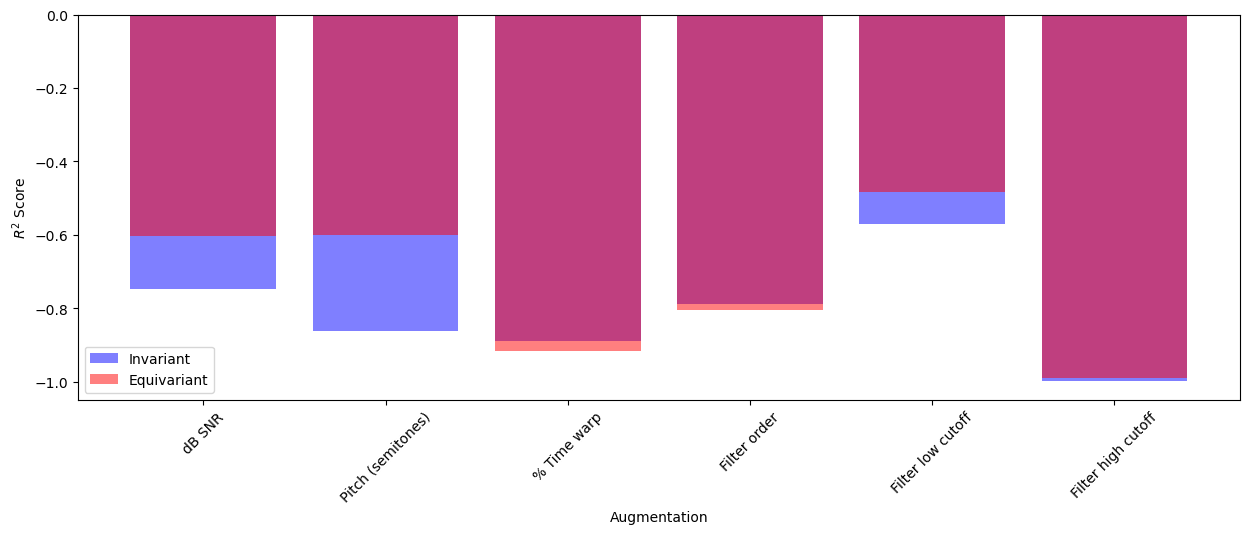

In [ ]:
print(f"Invariant Score: {score_1:.3f}, Equivariant Score: {score_2:.3f}")
plt.figure(figsize=(15, 5))
plt.bar(r2_invariant.keys(), r2_invariant.values(), color='blue', alpha=0.5, label='Invariant')
plt.bar(r2_equivariant.keys(), r2_equivariant.values(), color='red', alpha=0.5, label='Equivariant')
plt.xticks(rotation=45)
plt.xlabel('Augmentation')
plt.ylabel('$R^2$ Score')

plt.legend()